# N-BEATS: Neural Basis Expansion Analysis for Interpretable Time Series Forecasting

## Abstract
This paper introduces N-BEATS, a deep neural architecture for univariate time series point forecasting built entirely from backward and forward residual links and a deep stack of fully connected layers, without any time-series-specific components. The architecture achieves state-of-the-art performance on the M3, M4, and TOURISM competition datasets, improving forecast accuracy by 11% over a statistical benchmark and by 3% over the M4 competition winner (a hybrid neural/statistical model). The authors further show that N-BEATS can be configured to produce interpretable outputs resembling a trend-seasonality decomposition, without a significant loss in accuracy.

## Problems
- Despite success in vision and NLP, deep learning has historically struggled to outperform classical statistical methods in time series (TS) forecasting; in the M4 competition, all six pure ML entries ranked in the bottom half (23rd–57th of 60).
- The best-performing methods in major forecasting competitions were either classical statistical ensembles or hybrids that heavily depend on statistical components (e.g., the M4 winner combined an LSTM stack with a learnable Holt-Winters model), leading researchers to conclude that hybrid approaches were the only way forward.
- Deep learning models are generally treated as black boxes, lacking the interpretability that practitioners expect from traditional decomposition techniques (e.g., seasonality-trend-level analysis).

## Proposed Solutions
- **N-BEATS architecture**: A deep stack of fully connected "blocks," each performing a forecast/backcast split via basis expansion, connected through a *doubly residual stacking* principle (residual backcast connections between blocks plus hierarchical aggregation of partial forecasts).
- **Generic configuration (N-BEATS-G)**: Basis vectors $g^b_\ell$, $g^f_\ell$ are learned linear projections, imposing no time-series-specific inductive bias.
- **Interpretable configuration (N-BEATS-I)**: Two stacks with constrained, non-learnable basis functions — a low-degree polynomial basis for trend and a Fourier basis for seasonality — yielding human-interpretable partial forecasts.
- **Ensembling**: Combines models trained on different loss functions (sMAPE, MASE, MAPE), different input window lengths ($2H$ to $7H$), and different random initializations (180 models total) to boost robustness.

## Purpose
To determine whether pure deep learning, using no time-series-specific feature engineering, scaling, or statistical components, can match or surpass state-of-the-art statistical and hybrid forecasting methods, and to demonstrate that such an architecture can be extended to produce interpretable outputs without sacrificing accuracy.

## Methodology
### Basic Building Block
Each block $\ell$ takes input $\mathbf{x}_\ell$ and produces a forecast $\hat{\mathbf{y}}_\ell$ and backcast $\hat{\mathbf{x}}_\ell$ via a 4-layer fully connected network with ReLU activations producing expansion coefficients $\theta^f_\ell, \theta^b_\ell$, followed by basis layers:
$$
\hat{\mathbf{y}}_\ell = \sum_{i=1}^{\dim(\theta^f_\ell)} \theta^f_{\ell,i} \mathbf{v}^f_i, \qquad \hat{\mathbf{x}}_\ell = \sum_{i=1}^{\dim(\theta^b_\ell)} \theta^b_{\ell,i} \mathbf{v}^b_i
$$

### Doubly Residual Stacking
$$
\mathbf{x}_\ell = \mathbf{x}_{\ell-1} - \hat{\mathbf{x}}_{\ell-1}, \qquad \hat{\mathbf{y}} = \sum_{\ell} \hat{\mathbf{y}}_\ell
$$
Each block removes the portion of the signal it can explain before passing the residual to the next block; partial forecasts are aggregated hierarchically at the stack and network level.

### Interpretable Basis Functions
- **Trend** (polynomial of degree $p$):
$$
\hat{\mathbf{y}}^{tr}_{s,\ell} = \mathbf{T}\theta^f_{s,\ell}, \quad \mathbf{T} = [\mathbf{1}, \mathbf{t}, \dots, \mathbf{t}^p]
$$
- **Seasonality** (Fourier series):
$$
\hat{\mathbf{y}}^{seas}_{s,\ell} = \mathbf{S}\theta^f_{s,\ell}, \quad \mathbf{S} = [1, \cos(2\pi t), \dots, \sin(2\pi \lfloor H/2-1 \rfloor t)]
$$

### Evaluation Metrics
$$
sMAPE = \frac{200}{H}\sum_{i=1}^{H}\frac{|y_{T+i}-\hat{y}_{T+i}|}{|y_{T+i}|+|\hat{y}_{T+i}|}, \quad
MASE = \frac{1}{H}\sum_{i=1}^{H}\frac{|y_{T+i}-\hat{y}_{T+i}|}{\frac{1}{T+H-m}\sum_{j=m+1}^{T+H}|y_j - y_{j-m}|}
$$
$$
OWA = \frac{1}{2}\left(\frac{sMAPE}{sMAPE_{Naive2}} + \frac{MASE}{MASE_{Naive2}}\right)
$$

### Experimental Setup
- **Datasets**: M4 (100,000 series), M3 (3,003 series), TOURISM (1,311 series), plus supplementary experiments on ELECTRICITY and TRAFFIC.
- **Training**: Implemented in TensorFlow, Adam optimizer (lr = 0.001), batch size 1024, one model trained per forecast horizon; input window lengths mixed across $2H$–$7H$; early stopping via a held-out validation split.
- **Ablations**: Number of stacks/blocks, basis-function synergy (trend + seasonality vs. single type), ensemble size, and comparison of the doubly residual stacking topology against alternatives (PARALLEL, NO-RESIDUAL, LAST-FORWARD, NO-RESIDUAL-LAST-FORWARD, RESIDUAL-INPUT).

## Results
| Dataset | Metric | Best Prior Method | N-BEATS-G | N-BEATS-I | N-BEATS-I+G |
|---|---|---|---|---|---|
| M4 | OWA | 0.821 (M4 winner) | 0.797 | 0.798 | 0.795 |
| M3 | sMAPE | 12.71 (EXP) | 12.47 | 12.43 | 12.37 |
| TOURISM | MAPE | 19.35 (LeeCBaker) | 18.47 | 18.97 | 18.52 |

- On M4, the OWA gap between N-BEATS and the competition winner (0.026) exceeds the gap between the winner and the second-place entry (0.017).
- Statistical significance testing (paired t-test) showed N-BEATS significantly outperformed the M4 winner in 18 of 31 dataset sub-segments.
- Ablations confirmed that increasing stack/block depth monotonically improves validation sMAPE (up to 30 stacks, depth 150), that combining trend and seasonality bases outperforms either basis alone, and that the doubly residual stacking topology outperforms all tested alternative topologies.
- Performance degrades gracefully with smaller ensembles (18 vs. 180 models loses under 0.5% OWA).
- On ELECTRICITY and TRAFFIC datasets, N-BEATS matched or outperformed DeepAR, Deep State, Deep Factors, and MatFact despite using no covariates (e.g., day-of-week, hour-of-day).
- Interpretable-model outputs visually decomposed into a slowly varying trend component and a cyclical seasonality component, in contrast to the unstructured outputs of the generic model, while achieving comparable or better accuracy.

## Conclusions
The paper demonstrates that a pure deep learning architecture, without time-series-specific feature engineering, scaling, or statistical hybridization, can achieve state-of-the-art performance across heterogeneous forecasting benchmarks (M3, M4, TOURISM), refuting the prevailing view that hybrid statistical-neural methods are necessary. It further shows that imposing structured, non-learnable basis functions (polynomial and Fourier) enables interpretable forecast decomposition with no meaningful accuracy trade-off. The authors also draw a conceptual link between N-BEATS's block-wise residual refinement and meta-learning, framing the inner learning procedure as expansion-coefficient updates conditioned by an outer, gradient-learned parameterization.

# Mathematical and Statistical Content of N-BEATS

## 1. Forecasting Problem Setup
Given a history of length $T$, $[y_1,\dots,y_T]$, the goal is to predict the next $H$ values:
$$
\mathbf{y} \in \mathbb{R}^H = [y_{T+1}, y_{T+2}, \dots, y_{T+H}]
$$
A lookback window of length $t \le T$ is used as model input:
$$
\mathbf{x} \in \mathbb{R}^t = [y_{T-t+1}, \dots, y_T]
$$
**Role:** Defines the basic supervised learning task — mapping a past window $\mathbf{x}$ to a future window $\hat{\mathbf{y}}$.

## 2. Evaluation Metrics
These are scale-free error measures used to compare forecasts across time series with different magnitudes.

**sMAPE (symmetric Mean Absolute Percentage Error):**
$$
sMAPE = \frac{200}{H}\sum_{i=1}^{H}\frac{|y_{T+i}-\hat{y}_{T+i}|}{|y_{T+i}|+|\hat{y}_{T+i}|}
$$
Measures average percentage error, symmetric with respect to over- and under-forecasting.

**MAPE (Mean Absolute Percentage Error):**
$$
MAPE = \frac{100}{H}\sum_{i=1}^{H}\frac{|y_{T+i}-\hat{y}_{T+i}|}{|y_{T+i}|}
$$
Simple percentage error; can be unstable when $y_{T+i}$ is near zero.

**MASE (Mean Absolute Scaled Error):**
$$
MASE = \frac{1}{H}\sum_{i=1}^{H}\frac{|y_{T+i}-\hat{y}_{T+i}|}{\frac{1}{T+H-m}\sum_{j=m+1}^{T+H}|y_j - y_{j-m}|}
$$
Scales the error by the average error of a naive seasonal forecast (repeating the value from $m$ periods ago), making it comparable across series with different seasonal patterns.

**OWA (Overall Weighted Average):**
$$
OWA = \frac{1}{2}\left(\frac{sMAPE}{sMAPE_{Naive2}} + \frac{MASE}{MASE_{Naive2}}\right)
$$
A competition-specific composite score (used in M4) that normalizes both sMAPE and MASE against a naive seasonal benchmark, so $OWA=1.0$ represents naive-forecast-level performance; lower is better.

**Role:** These metrics are the yardsticks used throughout the paper to rank N-BEATS against competitors.

## 3. Basic Block Computation
Each block $\ell$ processes its input through 4 fully connected (FC) layers:
$$
\mathbf{h}_{\ell,1} = FC_{\ell,1}(\mathbf{x}_\ell), \quad \mathbf{h}_{\ell,2} = FC_{\ell,2}(\mathbf{h}_{\ell,1}), \quad \mathbf{h}_{\ell,3} = FC_{\ell,3}(\mathbf{h}_{\ell,2}), \quad \mathbf{h}_{\ell,4} = FC_{\ell,4}(\mathbf{h}_{\ell,3})
$$
$$
\theta^b_\ell = \text{LINEAR}^b_\ell(\mathbf{h}_{\ell,4}), \quad \theta^f_\ell = \text{LINEAR}^f_\ell(\mathbf{h}_{\ell,4})
$$
where a typical FC layer is:
$$
\mathbf{h}_{\ell,1} = \text{ReLU}(\mathbf{W}_{\ell,1}\mathbf{x}_\ell + \mathbf{b}_{\ell,1})
$$
**Role:** This is a standard deep feedforward network producing two sets of coefficients — one for reconstructing the input (backcast) and one for predicting the future (forecast). ReLU is the nonlinearity that lets the network learn complex, non-linear patterns.

## 4. Basis Expansion (Forecast and Backcast)
$$
\hat{\mathbf{y}}_\ell = \sum_{i=1}^{\dim(\theta^f_\ell)} \theta^f_{\ell,i} \mathbf{v}^f_i, \qquad \hat{\mathbf{x}}_\ell = \sum_{i=1}^{\dim(\theta^b_\ell)} \theta^b_{\ell,i} \mathbf{v}^b_i
$$
This is essentially a **linear combination of basis functions** $\mathbf{v}_i$, weighted by learned coefficients $\theta_i$ — the same principle behind Fourier series or polynomial regression: represent a complex signal as a weighted sum of simpler building blocks.

**Generic case (unconstrained basis):**
$$
\hat{\mathbf{y}}_\ell = \mathbf{V}^f_\ell \theta^f_\ell + \mathbf{b}^f_\ell, \qquad \hat{\mathbf{x}}_\ell = \mathbf{V}^b_\ell \theta^b_\ell + \mathbf{b}^b_\ell
$$
Here $\mathbf{V}^f_\ell$ is a learned matrix (essentially a linear projection layer), so the "basis functions" are whatever the network discovers during training — not constrained to any known functional form.

**Role:** Separates the network into (1) a part that learns *how much* of each basis pattern to use (coefficients) and (2) a part that defines *what* the patterns look like (basis vectors).

## 5. Doubly Residual Stacking
$$
\mathbf{x}_\ell = \mathbf{x}_{\ell-1} - \hat{\mathbf{x}}_{\ell-1}, \qquad \hat{\mathbf{y}} = \sum_{\ell} \hat{\mathbf{y}}_\ell
$$
The **backcast residual** subtracts what a block has already "explained" from the signal before passing it to the next block — analogous to residual learning in ResNets, but applied to the input signal itself rather than hidden activations. The **forecast aggregation** simply sums every block's partial forecast into the final prediction.

**Role:** This is the core architectural trick. It lets each block focus on modeling the part of the signal previous blocks couldn't capture (like sequential curve-fitting / boosting), while also producing an easily interpretable additive decomposition of the final forecast.

## 6. Trend Model (Polynomial Basis)
$$
\hat{y}_{s,\ell} = \sum_{i=0}^{p} \theta^f_{s,\ell,i}\, t^i
$$
where $t = [0,1,2,\dots,H-1]^T / H$ is a normalized time grid, and $p$ is a small polynomial degree (e.g., 2 or 3).

In matrix form:
$$
\hat{\mathbf{y}}^{tr}_{s,\ell} = \mathbf{T}\theta^f_{s,\ell}, \qquad \mathbf{T} = [\mathbf{1}, \mathbf{t}, \dots, \mathbf{t}^p]
$$
**Role:** A low-degree polynomial is a smooth, slowly changing curve — a natural mathematical way to represent long-term trend (e.g., a line for degree 1, a gentle curve for degree 2–3) without allowing it to overfit short-term fluctuations.

## 7. Seasonality Model (Fourier Basis)
$$
\hat{y}_{s,\ell} = \sum_{i=0}^{\lfloor H/2-1 \rfloor} \theta^f_{s,\ell,i}\cos(2\pi i t) + \theta^f_{s,\ell,i+\lfloor H/2\rfloor}\sin(2\pi i t)
$$
In matrix form:
$$
\hat{\mathbf{y}}^{seas}_{s,\ell} = \mathbf{S}\theta^f_{s,\ell}, \qquad \mathbf{S} = [1, \cos(2\pi t), \dots, \sin(2\pi\lfloor H/2-1\rfloor t)]
$$
**Role:** This is a truncated Fourier series — the standard mathematical tool for representing periodic (cyclical) signals as sums of sine and cosine waves of different frequencies. Constraining a stack to this basis forces its output to look cyclical, which is what seasonal patterns (daily, weekly, yearly cycles) look like.

## 8. Normalized Deviation (ND) — Used in Supplementary Experiments
$$
ND = \frac{\sum_{i,t}|\hat{Y}_{it} - Y_{it}|}{\sum_{i,t}|Y_{it}|}
$$
**Role:** An aggregate absolute-error metric normalized by total magnitude, used to compare against DeepAR, Deep State, Deep Factors, and MatFact on the ELECTRICITY and TRAFFIC datasets — analogous to a global (rather than per-series) version of MAPE.

## 9. Averaging Formulas for Aggregated Metrics
For M3:
$$
sMAPE_{Average} = \frac{N_{Year}}{N_{Tot}}sMAPE_{Year} + \frac{N_{Quart}}{N_{Tot}}sMAPE_{Quart} + \frac{N_{Month}}{N_{Tot}}sMAPE_{Month} + \frac{N_{Others}}{N_{Tot}}sMAPE_{Others}
$$
For TOURISM (analogous, without an "Others" term):
$$
MAPE_{Average} = \frac{N_{Year}}{N_{Tot}}MAPE_{Year} + \frac{N_{Quart}}{N_{Tot}}MAPE_{Quart} + \frac{N_{Month}}{N_{Tot}}MAPE_{Month}
$$
where each $N$ is the product of the number of series in that frequency group and its forecast horizon.

**Role:** A weighted average — larger subsets (more series × longer horizon) contribute proportionally more to the overall reported metric, ensuring a fair aggregate score across frequencies.

## 10. Statistical Significance Testing
The paper uses a **two-sided paired t-test** to compare N-BEATS against the M4 competition winner (Smyl's model) on each of 31 dataset sub-segments (combinations of domain type and sampling frequency), reporting the mean sMAPE difference and its standard error, with bold entries indicating significance at the 99% confidence level.

**Role:** Confirms that N-BEATS's improvements are not due to random chance but are statistically robust across many independent subsets of the data (18 of 31 segments showed significant improvement).

## 11. Ensembling as a Statistical Aggregation Method
The ensemble prediction is computed as the **median** of 180 individually trained models, which vary by:
- Loss function used (sMAPE, MASE, or MAPE),
- Input window length ($2H, 3H, \dots, 7H$),
- Random initialization (bagging, per Breiman, 1996).

**Role:** The median is a robust central-tendency statistic (less sensitive to outlier model predictions than the mean), and combining diverse models acts as a variance-reduction / regularization technique — empirically shown to outperform dropout or L2 regularization in this setting.

## Summary Table

| Concept | Mathematical Tool | Purpose in Paper |
|---|---|---|
| Forecast accuracy | sMAPE, MAPE, MASE, OWA | Standard scale-free error metrics for comparison |
| Block transformation | Fully connected layers + ReLU | Learn nonlinear mapping from input window to coefficients |
| Signal reconstruction | Linear basis expansion | Represent forecast/backcast as weighted sum of basis vectors |
| Sequential refinement | Doubly residual stacking | Each block models the residual left by previous blocks |
| Long-term trend | Polynomial basis | Smooth, slowly varying component |
| Cyclical pattern | Fourier basis | Periodic component |
| Aggregate error (multi-series) | Normalized Deviation (ND) | Compare against RNN-based baselines |
| Weighted aggregation | Weighted average by sample count | Fairly combine metrics across frequency subsets |
| Robust hypothesis testing | Paired t-test | Validate statistical significance of improvements |
| Ensemble aggregation | Median over bagged models | Reduce variance, improve generalization |

# Problems, Limitations, and Proposed Solutions in N-BEATS

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution in N-BEATS |
|---|---|---|---|
| 1 | Deep learning models generally underperform classical statistical methods in univariate time series forecasting. | In the M4 competition, all six pure ML submissions ranked in the bottom half (23rd–57th of 60 entries), and most top-ranking methods were statistical ensembles, undermining confidence in pure DL approaches. | Proposes a pure deep learning architecture (no time-series-specific components) that empirically outperforms statistical and hybrid benchmarks on M3, M4, and TOURISM. |
| 2 | Top-performing neural models rely heavily on statistical components. | The M4 winner (Smyl, 2020) is a hybrid combining a dilated LSTM/attention stack with a learnable Holt-Winters model, leading researchers (Makridakis et al., 2018b) to conclude that hybridization is "the way forward," discouraging exploration of pure DL. | Demonstrates that a generic configuration using only fully connected layers and residual links, with no statistical or time-series-specific feature engineering, matches or exceeds hybrid performance. |
| 3 | Models are often hand-crafted per forecast horizon or dataset domain. | Smyl's winning M4 model required architectures individually adjusted to each forecast horizon, limiting generalizability and reproducibility across datasets. | Uses one fixed architecture and hyperparameter set (per horizon-length grouping) that generalizes across M3, M4, and TOURISM without domain-specific redesign. |
| 4 | Deep architectures used for forecasting (e.g., ResNet, DenseNet-style stacking) are difficult to interpret. | Classical residual and densely connected architectures improve trainability but produce internal representations that are not human-interpretable, unlike traditional decomposition methods (e.g., STL, X13-ARIMA). | Introduces a doubly residual stacking topology with backcast/forecast decomposition, enabling an interpretable configuration where stack outputs correspond to distinct, human-readable components. |
| 5 | No established mechanism exists for injecting interpretability into DL forecasting without harming accuracy. | Prior interpretable statistical decompositions (trend-seasonality) are not naturally compatible with deep learning pipelines, forcing a tradeoff between interpretability and the accuracy gains of DL. | Constrains basis functions $g^b_{s,\ell}, g^f_{s,\ell}$ to a low-degree polynomial (trend) and Fourier series (seasonality), producing decomposed, interpretable partial forecasts with no significant loss in accuracy. |
| 6 | Deep architectures for TS forecasting are hard to train at depth. | Vanilla deep feedforward and even standard residual networks can suffer from poor gradient flow when scaled to many layers, limiting achievable network depth and expressive capacity. | Applies a hierarchical residual structure where each block's backcast removes explained signal from the input to the next block, and forecasts are aggregated hierarchically, improving gradient flow and enabling networks up to 150 layers deep. |
| 7 | Prior neural forecasting models (e.g., DeepAR, Deep State, Deep Factors) rely on covariates and multivariate structure. | These models require auxiliary features (e.g., day-of-week, hour-of-day) and are tailored to multivariate or covariate-rich settings, restricting applicability to simpler univariate series. | Shows N-BEATS matches or outperforms these covariate-dependent models on ELECTRICITY and TRAFFIC datasets using only the raw univariate signal, with no external covariates. |
| 8 | Lack of clarity on which architectural components (residual links, forecast aggregation) actually drive performance gains. | Existing ablation studies in the literature rarely isolate the contribution of specific residual/aggregation design choices in deep TS architectures. | Conducts a systematic ablation (PARALLEL, NO-RESIDUAL, LAST-FORWARD, NO-RESIDUAL-LAST-FORWARD, RESIDUAL-INPUT vs. N-BEATS-DRESS) demonstrating the doubly residual stacking topology provides a consistent empirical advantage. |
| 9 | Limited understanding of computational efficiency tradeoffs in ensembling for forecasting. | Prior competition-winning approaches (e.g., M4 winner) rely on large, often unexamined ensembles, without clear guidance on how ensemble size affects the accuracy/cost tradeoff. | Provides an explicit ensemble-size ablation, showing state-of-the-art performance is retained even with a 10x smaller ensemble (18 vs. 180 models), clarifying the accuracy-compute tradeoff. |

In [ ]:
# ---- 0. Install / imports ----
# XLRD is the engine that allow pandas to read dataset from Excel sheets into DataFrames
# -q is a flag that making the installation goes silent
!pip install -q xlrd    # needed to read legacy .xls files

# io - input/output operation library, converting raw byte streams into memory buffers
# math - provides stnadard math funcitons that allows us to operate using math funciton (log, triangonmetrics)
# os is a library that allow us to navigate the files system, read files, print directory sturctures.
import io, math, os

import numpy as np # core array-processing library in python, (create arrys, manipulate them, do math funciton on array)
import pandas as pd # pandas is used for downloading/loading/filter/structuring our dataset into dataframes
import torch # torch is the core pytorch package for managing multi-dim tensors (format tensors with neural network)
import torch.nn as nn # contains building block for creating deep neural network (Linear, Flatten, Conv2d, ...)

# Dataset is a base class that wraps our time-series data and create a pytorch compatible dataset object
# DataLoader will be our main class for creating batches/shuffling those samples ...
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt # it will be our main plotting interface for creating plots/graphs/line charts

import matplotlib.gridspec as gridspec # our main funciton for creating multi-panel custom layout

from IPython.display import Image as IPImage, display # allow dipalying images/grpahs inline direclty in google colab

In [ ]:
SEED = 42 # arbitrary value (you can chooose whatever value!)

np.random.seed(SEED)
torch.manual_seed(SEED)
# choose a device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
DEVICE

device(type='cuda')

In [ ]:
file_name = "M3C.xls"

my_dataaset = pd.read_excel(file_name, sheet_name="M3Month")
my_dataaset

,Series,N,NF,Category,Starting Year,Starting Month,1,2,3,4,...,135,136,137,138,139,140,141,142,143,144
0,N1402,68,18,MICRO,1990,1,2640.0,2640.0,2160.0,4200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N1403,68,18,MICRO,1990,1,1680.0,1920.0,120.0,1080.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N1404,68,18,MICRO,1990,1,1140.0,720.0,4860.0,1200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N1405,68,18,MICRO,1990,1,180.0,940.0,2040.0,800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N1406,68,18,MICRO,1990,1,2000.0,1550.0,4450.0,3050.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,N2825,71,18,OTHER,0,0,3295.5,3301.9,3244.6,3221.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1424,N2826,71,18,OTHER,0,0,4922.8,4924.5,4960.9,4930.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425,N2827,71,18,OTHER,0,0,4142.8,4096.0,4074.8,4015.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1426,N2828,71,18,OTHER,0,0,3004.6,2983.4,2983.4,2974.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
my_dataaset.iloc[:, :4]

,Series,N,NF,Category
0,N1402,68,18,MICRO
1,N1403,68,18,MICRO
2,N1404,68,18,MICRO
3,N1405,68,18,MICRO
4,N1406,68,18,MICRO
...,...,...,...,...
1423,N2825,71,18,OTHER
1424,N2826,71,18,OTHER
1425,N2827,71,18,OTHER
1426,N2828,71,18,OTHER


In [ ]:
my_dataaset.iloc[:, 6:] # our actual datapoint (our time-series data to trian the model on)

,1,2,3,4,5,6,7,8,9,10,...,135,136,137,138,139,140,141,142,143,144
0,2640.0,2640.0,2160.0,4200.0,3360.0,2400.0,3600.0,1920.0,4200.0,4560.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1680.0,1920.0,120.0,1080.0,840.0,1440.0,480.0,720.0,4080.0,1560.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1140.0,720.0,4860.0,1200.0,3150.0,2130.0,1800.0,2010.0,2880.0,1650.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,180.0,940.0,2040.0,800.0,1000.0,520.0,500.0,400.0,1760.0,1520.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000.0,1550.0,4450.0,3050.0,3050.0,2250.0,2200.0,2450.0,4900.0,5300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,3295.5,3301.9,3244.6,3221.2,3214.8,3193.6,3180.9,3197.8,3210.6,3189.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1424,4922.8,4924.5,4960.9,4930.2,4884.8,4821.2,4787.1,4740.0,4725.8,4679.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425,4142.8,4096.0,4074.8,4015.3,3964.4,3919.8,3898.6,3877.3,3832.7,3807.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1426,3004.6,2983.4,2983.4,2974.9,2989.7,3006.7,3006.7,3000.4,2989.7,2991.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ---- 2. Parse each sheet ----

fname = "M3C.xls" # Excel file sheet

# define sheets name
SHEETS = ["M3Year", "M3Quart", "M3Month", "M3Other"]

# this function will parse (read) our time-series dataset

def load_m3_sheet(xls_path, sheet_name):
    # header=0 (use the zero-th row to name our columns)
    raw = pd.read_excel(xls_path, sheet_name=sheet_name, header=0)

    meta = raw.iloc[:, :4] # access the first 4 columns (the metadata about our time-series dastset)

    meta.columns = ["Series", "N", "NF", "Category"]

    data = raw.iloc[:, 6:]              # data always starts at column G (index 6) in M3C.xls

    out = [] # a new empty list

    for i in range(len(raw)): # iteration loop
        # create a try-except block (that catches all the errors/corrupted in our dataset)

        try: # try the following line of codes if it works that is nice other skip this row
            n_obs, n_fore = int(meta.loc[i, "N"]), int(meta.loc[i, "NF"])
            # if can not cast to integers that means  there is someting wrong with these numbers
        except (ValueError, TypeError):
            continue # entirely skip that row (without throwing an error)

        # dynamically return the full time-series sequence (shorter or longer)
        # convert this time-series sequnence into numbers
        # convert into numpy array with the data type (numpy float 32-bit floating-point numpy array)
        vals = pd.to_numeric(data.iloc[i, :n_obs], errors="coerce").to_numpy(dtype=np.float32)

        # a final safe-check to check whether the time-series sequnce contains (NaNs) Not-a-Number
        # if this time-serise seuqence is lower than the n_obs
        if len(vals) < n_obs or np.isnan(vals).any():
            continue # skip this time-series seuqeunce

        out.append({
            "id": str(meta.loc[i, "Series"]), # uniuque ID
            "category": str(meta.loc[i, "Category"]).strip(),
            "N": n_obs, "NF": n_fore, "freq": sheet_name,
            "values": vals, # create a dict of those valid point
        })
    return out
# loop over the sheets values and run the funciton of the pre-processing over those sheets
all_series = {s: load_m3_sheet(fname, s) for s in SHEETS}

for s, lst in all_series.items():
    print(f"{s}: {len(lst)} series parsed")

M3Year: 645 series parsed
M3Quart: 756 series parsed
M3Month: 1428 series parsed
M3Other: 174 series parsed


In [ ]:
load_m3_sheet("M3C.xls", "M3Month")

[{'id': 'N1402',
  'category': 'MICRO',
  'N': 68,
  'NF': 18,
  'freq': 'M3Month',
  'values': array([2640., 2640., 2160., 4200., 3360., 2400., 3600., 1920., 4200.,
         4560.,  480., 3720., 5640., 2880., 1800., 3120., 2400., 2520.,
         9000., 2640., 3120., 2880., 8760., 5160., 2160., 8280., 4920.,
         3120., 6600., 4080., 5880., 1680., 6720., 2040., 6480., 1920.,
         3600., 2040., 2760., 3840.,  960., 2280., 1320., 2160., 4800.,
         3000., 3120., 5880., 2640., 2400., 2280.,  480., 5040., 1920.,
          840., 2520., 1560., 1440.,  240., 1800., 4680., 1800., 1680.,
         3720., 2160.,  480., 2040., 1440.], dtype=float32)},
 {'id': 'N1403',
  'category': 'MICRO',
  'N': 68,
  'NF': 18,
  'freq': 'M3Month',
  'values': array([1680., 1920.,  120., 1080.,  840., 1440.,  480.,  720., 4080.,
         1560.,  480.,  720., 6120., 2040., 3960., 2160.,  120., 1200.,
         1080., 1080., 1080., 2160.,  240., 1440., 1200., 1560., 2520.,
          600., 1560., 3240., 

In [ ]:
## ---- 3. Choose which frequency subset to train on ----
# Paper trains ONE model per forecast horizon (Sec. 5.2). We use
# M3Month (H=18) -- the largest M3 subset (1,428 series, Table 3)
# and the paper's primary reported horizon for this dataset.
FREQ = "M3Month"
H = 18 # the number of future data point to predict (forecast)
# just reutrn the time-sereis lists of horizon of future = 18
series_pool = [s for s in all_series[FREQ] if s["NF"] == H]

print(f"Using {len(series_pool)} series from {FREQ}, horizon H={H}")

# Official M3 protocol (per the Competition sheet): last NF points
# of each series are held out as the true evaluation target.
for s in series_pool:
    s["train_hist"]  = s["values"][:-H] # extracting the training data points (the history)
    s["test_target"] = s["values"][-H:] # extracting the test target (future points)

# the authors of the paper tesed with many horizon length (1H, 2H, 3H, 4H, 5H, 6H, 7H)

T_IN = 3 * H  # lookback length; paper mixes 2H..7H (Sec. 5.2), we fix one multiple for simplicity

# every time-seires should include at least one complete X & y pairs (input-target pairs)
series_pool = [s for s in series_pool if len(s["train_hist"]) >= T_IN + H]

print(f"{len(series_pool)} series long enough for T_in={T_IN}")

Using 1428 series from M3Month, horizon H=18
1076 series long enough for T_in=54


In [ ]:
54 + 18

72

In [ ]:
3 * 18 # 4.5 years of monthly context

54

In [ ]:
series_pool

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
series_pool[0]

{'id': 'N1679',
 'category': 'MICRO',
 'N': 126,
 'NF': 18,
 'freq': 'M3Month',
 'values': array([ 8000.,  5120.,  4720.,  7020.,  3840.,  7360.,  5040., 10800.,
         6580.,  8520.,  9460.,  7560.,  7060.,  4560.,  4660.,  6040.,
         4260.,  5840.,  5020., 10040., 10060.,  9100.,  5840.,  6660.,
         5680.,  5820.,  3280.,  3000.,  3800.,  6040.,  5040.,  7100.,
         8140.,  6820.,  9000.,  6840.,  5020.,  3020.,  6960.,  3980.,
         3660.,  2740.,  4760.,  8520.,  4220.,  7160.,  7040.,  4640.,
         7440.,  3900.,  6800.,  4840.,  3080.,  5220.,  3840.,  2860.,
         6780.,  5480.,  3700.,  4460.,  4180.,  4520.,  3900.,  3580.,
         2120.,  4560.,  4500.,  5660.,  4240., 10160.,  7500.,  7180.,
         7800.,  5240.,  5480.,  3900.,  2920.,  4100.,  4540.,  2520.,
         4920.,  3080.,  2800.,  2160.,  3500.,  3420.,  3480.,  1900.,
         2220.,  2620.,  5160.,  2520.,  4740.,  3380.,  3380.,  2640.,
         3640.,  4840.,  1700.,  2660.,  2920.

In [ ]:
max(1, int(0.15 * len(series_pool)))

161

In [ ]:
n_val_series = max(1, int(0.15 * len(series_pool)))
# non-duplicate items
set(s["id"] for s in series_pool[:n_val_series])

{'N1679',
 'N1680',
 'N1681',
 'N1682',
 'N1683',
 'N1684',
 'N1685',
 'N1686',
 'N1687',
 'N1688',
 'N1689',
 'N1690',
 'N1691',
 'N1692',
 'N1693',
 'N1694',
 'N1695',
 'N1696',
 'N1697',
 'N1698',
 'N1699',
 'N1700',
 'N1701',
 'N1702',
 'N1703',
 'N1704',
 'N1705',
 'N1706',
 'N1707',
 'N1708',
 'N1709',
 'N1710',
 'N1711',
 'N1712',
 'N1713',
 'N1714',
 'N1715',
 'N1716',
 'N1717',
 'N1718',
 'N1719',
 'N1720',
 'N1721',
 'N1722',
 'N1723',
 'N1724',
 'N1725',
 'N1726',
 'N1727',
 'N1728',
 'N1729',
 'N1730',
 'N1731',
 'N1732',
 'N1733',
 'N1734',
 'N1735',
 'N1736',
 'N1737',
 'N1738',
 'N1739',
 'N1740',
 'N1741',
 'N1742',
 'N1743',
 'N1744',
 'N1745',
 'N1746',
 'N1747',
 'N1748',
 'N1749',
 'N1750',
 'N1751',
 'N1752',
 'N1753',
 'N1754',
 'N1755',
 'N1756',
 'N1757',
 'N1758',
 'N1759',
 'N1760',
 'N1761',
 'N1762',
 'N1763',
 'N1764',
 'N1765',
 'N1766',
 'N1767',
 'N1768',
 'N1769',
 'N1770',
 'N1771',
 'N1772',
 'N1773',
 'N1774',
 'N1775',
 'N1776',
 'N1777',
 'N1778',


In [ ]:
# ---- 4. Build sliding (lookback, horizon) training/validation windows ----
# from each series' TRAINING history only (test_target is never seen
# during training -- it is reserved for the final held-out evaluation).

# we are building a sliding window (lookback window length, horizon forecast window length)

rng = np.random.default_rng(SEED)
# selecting our validation (evaluation) samples (held-out unseen during training)
n_val_series = max(1, int(0.15 * len(series_pool)))

# choosing (sampling) those unseen validation samples
val_ids = set(s["id"] for s in series_pool[:n_val_series])

# this function will create both lookback + forecast windows (X + y)
def build_windows(pool, windows_per_series=8):
    trX, trY, trT, vaX, vaY, vaT = [], [], [], [], [], []

    for s in pool:

        hist = s["train_hist"] # extracting the training history (lookback window)
        # lookback window + forcast window
        # T_IN = 3 * H (H = 18) = 54
        # hi = 18 (H = 18) = 18 points
        lo, hi = T_IN, len(hist) - H


        if hi <= lo:
            continue # that means ignore (skip) that time series

        # an anchor point is a cut-off value that specifies where to cut off our present from that past
        # everything behind a is a lookback window (54)
        # everthing after a is a future (forecast) window (18)
        # generating anchor value to cut-off our time-series into (X, y)
        anchors = rng.integers(lo, hi, size=min(windows_per_series, hi - lo))

        for a in anchors:
            # we are using the past to predict the future
            # we are creating X (lookback past window of size 54)
            # we are creating y (future forecast window of size 18)
            x, y = hist[a - T_IN:a], hist[a:a + H]

            if s["id"] in val_ids:
                vaX.append(x); vaY.append(y); vaT.append(s["category"])
            else:
                trX.append(x); trY.append(y); trT.append(s["category"])

    return (np.stack(trX), np.stack(trY), np.array(trT),
            np.stack(vaX), np.stack(vaY), np.array(vaT))


X_train, Y_train, T_train, X_val, Y_val, T_val = build_windows(series_pool)

print(f"Train windows: {len(X_train)} | Val windows: {len(X_val)}")

CATEGORIES = sorted(set(T_train.tolist()) | set(T_val.tolist()))  # real M3 categories, e.g. MICRO/FINANCE/...
print("Categories found:", CATEGORIES)

# creating a dataset wrapper that can wrap our dataset into pytorch compatible dataset
class M3Dataset(Dataset):
    def __init__(self, X, Y, cats):
        # convert our X time series data into pytorch tensor of type float 32
        self.X = torch.tensor(X, dtype=torch.float32)
        # convert our Y time seris future forecast into pytorch tensor of data type float 32
        self.Y = torch.tensor(Y, dtype=torch.float32)

        self.cats = cats
    # how many samples we have a dataset split

    def __len__(self): return len(self.X) # len(X) = len(y)
    # a function to get an item in a lazy fashion (format)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx], idx

# create a dataset of map-style dataset object
train_ds, val_ds = M3Dataset(X_train, Y_train, T_train), M3Dataset(X_val, Y_val, T_val)

# create our dataloaders (creating batches (64 samples))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True) # for the training datset randmize the order of the samples
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

xb, yb, _ = next(iter(train_loader))

print(f"Batch x {tuple(xb.shape)}  Batch y {tuple(yb.shape)}  y range [{yb.min():.1f},{yb.max():.1f}]")

Train windows: 7268 | Val windows: 1288
Categories found: ['DEMOGRAPHIC', 'FINANCE', 'INDUSTRY', 'MACRO', 'MICRO', 'OTHER']
Batch x (64, 54)  Batch y (64, 18)  y range [160.0,30150.0]


In [ ]:
train_ds[0]

(tensor([1080., 1260.,  910.,  800., 1010., 1590.,  770.,  700.,  870., 1020.,
         1010., 1290., 1380., 1120., 1810., 1280., 1330., 2810., 1100.,  950.,
          890., 1230., 1270., 1200., 1100., 1130., 2340., 1300., 1580., 2430.,
         2070., 1660., 1800., 1680., 1680., 2500., 2480., 2100., 2360., 1910.,
         3370., 2400., 2100., 2300., 1740., 3040., 1370., 3000., 2310., 2500.,
         4300., 1340., 1690., 3610.]),
 tensor([2270., 3530., 1850., 2490., 2680., 2450., 3200., 2210., 2350., 2920.,
         3800., 2840., 4960., 4060., 2530., 3260., 3440., 3350.]),
 0)

In [ ]:
len(train_ds[2][0])

54

In [ ]:
len(train_ds[2][1])

18

In [ ]:
len(train_ds[2][0]) + len(train_ds[2][1])

72

In [ ]:
# ============================================================
# 5. N-BEATS MODEL (identical architecture to the paper's
#    interpretable configuration -- Sec. 3.3, Eqs. 1-3)
# ============================================================
# this block of code define the building block unit of the N-BEATS architecture
# 1. allow (support) device move (model.to(device))
# 2. allow (support) autograd module to compute gradients and improve weights/biases during training
class NBeatsBlock(nn.Module):

    def __init__(self, input_size, hidden_size, backcast_basis, forecast_basis):
        super().__init__()
        # input_size : the input size of the time series sequence (B, T_IN) -> (64, 54)
        # hidden_size: the high-dim feature represenation (B, hidden_size) -> (64, 164)
        # backcast_basis: a backcast basis size
        # forecast_basis: a forecast basis size

        # this sequential list of layers acts as a deep non-linear feature extractor
        self.fc_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size), # a linear fully-conncted layer that projects into hidden_size
            nn.ReLU(), # introducing non-linear activation function (non-linearity) (Max(0, a))
            nn.Linear(hidden_size, hidden_size), # a second linear fully-connected layer
            nn.ReLU(), # introduce non-linearity
            nn.Linear(hidden_size, hidden_size), # introducing capbililty (to learn high-dim complex feature)
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), # (backcast expansion coeff, forecast expansion coeff) (theta_b, theta_f)
        )


        # project our hidden space into backcast expansion coeff shape
        self.theta_b_fc = nn.Linear(hidden_size, backcast_basis.shape[1], bias=False)
        # project our hidden space into forecast expansion coeff shape
        self.theta_f_fc = nn.Linear(hidden_size, forecast_basis.shape[1], bias=False)

        # we are using register buffer to gain 3 advantages:
        # 1. device synch: automatically move our parameters (weights/biases) to the target device
        # 2. no gradient computation: backprop will not be able to adjust these state tensors (non-learnable)
        # 3. if you save the model it will be saved with the model (load_state_dict + state_dict())
        self.register_buffer("backcast_basis", backcast_basis) # the functional basis functions
        self.register_buffer("forecast_basis", forecast_basis) # the functional basis fucntion


    def forward(self, x):
        h = self.fc_stack(x) # apply the 4 FC layers one by one with RELU activation
        # creating backcast expansion coeff + creating a forecast expansion coeff \
        theta_b, theta_f = self.theta_b_fc(h), self.theta_f_fc(h)
        # @ notation is just doing matrix mulitiplication
        # theta_b @ self.backcast_basis.T - produces our final reconsturcted backcast window
        # theta_f @ self.forecast_basis.T - produces the forecast (prdiction) of future window value
        return theta_b @ self.backcast_basis.T, theta_f @ self.forecast_basis.T


# this function constructs a polynomial basis matrix T
def make_trend_basis(length, degree):
    # length: the length of the time vector
    # degree: the powers that we can raise the time vector to

    # generate a discrete grid time by using numpy library (normalized time vector)
    # normalizing prevent number explosion by making sure when we rasie to high-degrees of ploynomial
    # np.array(0, 1, 2, 3, 4)
    # np.array(0, 1/L, 2/L, 3/L, 4/L)
    t = np.arange(length, dtype=np.float32) / length
    # T^0 = np.array(1, 1, 1, 1) (a vector of all ones)
    # T^1 = np.array(0, 1/L, 2/L, 3/L) (a vector of linear trend)
    # T^2 = np.array(0^2, 1^2,...) a quadratic equation of the time series sequence
    # T^3 = np.array(0^3, 1Y3, ...) a cubic equaiton of the time seires sequence
    return torch.tensor(np.stack([t**p for p in range(degree+1)], axis=1), dtype=torch.float32)

# this function constructes a Fourier series analysis for seasonality stacks
def make_seasonality_basis(length):
    # a normalized time vector (divide by length)
    # dividing by length ensure we do not get into number explosion problem (when computing high-polynomial degrees)
    t = np.arange(length, dtype=np.float32) / length

    n_harm = length // 2

    # compute a pair-wise waveforms of sine and cosine function (Fourier analysis)
    basis = [np.cos(2*np.pi*i*t) for i in range(n_harm)] + [np.sin(2*np.pi*i*t) for i in range(n_harm)]


    return torch.tensor(np.stack(basis, axis=1), dtype=torch.float32)

# this class builds the NBeatsStack module which gorups multiple NBeatsBlocks together
class NBeatsStack(nn.Module):

    def __init__(self, block, num_blocks):
        # block : a block instance of the NBeatsBlock
        # num_blocks: a number of repeated NBeatsBlocks inside a stack

        super().__init__(); self.block, self.num_blocks = block, num_blocks

    def forward(self, x):
        # x is the input to the method forward
        # residual is the same ideas as ResNet paper and set here to be as X
        # stack_forecast: a running sum acculumator of the forecast prediction

        residual, stack_forecast = x, 0.0

        for _ in range(self.num_blocks):
            # implement three operation per single loop  (step)
            # 1. Forward Pass
            # it will return two things (backcast coeff of expansion, forecast expansion of coeff)
            backcast, forecast = self.block(residual)
            # 2. Residual calcuation (stripping awasy the already processed explainable portion)
            # just keeping the remaining explained porition of the residual connection
            residual = residual - backcast
            # 3. accumulate the partial forecast with the total forecast variable
            stack_forecast = stack_forecast + forecast


        return residual, stack_forecast

class NBeatsInterpretable(nn.Module):

    def __init__(self, t_in, horizon, hidden_size=64, trend_degree=2, num_blocks=3):
        super().__init__()

        # NBeatsBlock for Trend Stack Analysis
        trend_block = NBeatsBlock(t_in, hidden_size,
                                   make_trend_basis(t_in, trend_degree), make_trend_basis(horizon, trend_degree))

        # NBeatsBlock for the seasonality stack analysis
        season_block = NBeatsBlock(t_in, hidden_size,
                                    make_seasonality_basis(t_in), make_seasonality_basis(horizon))

        # create a NBeatsStack of Trend/Season analysis stacks

        self.trend_stack = NBeatsStack(trend_block, num_blocks)

        # create a stack of 3 different block os season blocks inside one NBeatsStack
        self.season_stack = NBeatsStack(season_block, num_blocks)


    def forward(self, x):
        # residual is our remaining unexaplained (unmodelded) part of the X
        # y_trend our accumulated combined forecast
        residual, y_trend = self.trend_stack(x)

        _, y_season = self.season_stack(residual)

        return y_trend + y_season, y_trend, y_season

# historical time series length = (3H) = 3 * 18 = 54
# forecasted future point (1H) = 1 * 18 = 18

model = NBeatsInterpretable(T_IN, H).to(DEVICE)
# filtering our non-learnable (non-trainable) param out of the calculation

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 36,992


In [ ]:
# ---- 6. Losses (paper Sec. 3.4: sMAPE / MASE / MAPE) ----
EPS = 1e-8


def smape_loss(y, yh):
    denom = (y.abs() + yh.abs()).detach() + EPS
    return (200.0 * (y - yh).abs() / denom).mean()


def mape_loss(y, yh):
    return (100.0 * (y - yh).abs() / (y.abs() + EPS)).mean()


def mase_loss(y, yh, x_hist):
    scale = (x_hist[:, 1:] - x_hist[:, :-1]).abs().mean(dim=1, keepdim=True) + EPS
    return ((y - yh).abs() / scale).mean()
# we are using Adam optimizer to optimize our weight/biases
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 5
history = {"train_smape": [], "val_smape": [], "train_mape": [], "val_mape": [], "train_mase": [], "val_mase": []}
# one empty list for each category (finance, micro, macro, industry)
per_cat_history = {c: [] for c in CATEGORIES}

def run_epoch(loader, train_mode):
    # set the model to the training mode
    model.train(train_mode)

    tot_s = tot_m = tot_a = 0.0; nb = 0
    # tracks the category error for each single category (in an empty list)
    cat_err = {c: [] for c in CATEGORIES}

    for xb, yb, idxb in loader:
        # xb = size = (64, 54)
        # yb = size = (64, 18)
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        # zero out the old (previous) gradients if we are training

        if train_mode: optimizer.zero_grad()
        # a forward pass
        yh, _, _ = model(xb)

        #compute the loss value of the SMAPE
        loss = smape_loss(yb, yh)

        with torch.no_grad(): # disable the gradient clac

            m_mape = mape_loss(yb, yh);
            m_mase = mase_loss(yb, yh, xb)

            # a simple loss claculation of the SMAPE
            per_sample = (200.0 * (yb - yh).abs() / ((yb.abs()+yh.abs())+EPS)).mean(dim=1)


        if train_mode: loss.backward(); optimizer.step()

        tot_s += loss.item();
        tot_m += m_mape.item();
        tot_a += m_mase.item();
        nb += 1

        cats = (train_ds.cats if train_mode else val_ds.cats)[idxb.numpy()]


        for c, e in zip(cats, per_sample.cpu().numpy()): cat_err[c].append(e)

    cat_avg = {c: (np.mean(v) if v else np.nan) for c, v in cat_err.items()}

    return tot_s/nb, tot_m/nb, tot_a/nb, cat_avg

print("=== Training on real M3 data (5 epochs) ===")
for ep in range(1, N_EPOCHS+1):
    tr = run_epoch(train_loader, True);
    va = run_epoch(val_loader, False)

    history["train_smape"].append(tr[0]); history["val_smape"].append(va[0])
    history["train_mape"].append(tr[1]);  history["val_mape"].append(va[1])
    history["train_mase"].append(tr[2]);  history["val_mase"].append(va[2])

    for c in CATEGORIES: per_cat_history[c].append(va[3].get(c, np.nan))
    print(f"Epoch {ep}: train sMAPE={tr[0]:.3f} | val sMAPE={va[0]:.3f} MAPE={va[1]:.3f} MASE={va[2]:.3f}")

=== Training on real M3 data (5 epochs) ===
Epoch 1: train sMAPE=10.966 | val sMAPE=23.161 MAPE=26.968 MASE=0.756
Epoch 2: train sMAPE=9.899 | val sMAPE=23.122 MAPE=26.525 MASE=0.750
Epoch 3: train sMAPE=9.738 | val sMAPE=24.522 MAPE=28.747 MASE=0.792
Epoch 4: train sMAPE=9.666 | val sMAPE=23.590 MAPE=28.432 MASE=0.769
Epoch 5: train sMAPE=9.618 | val sMAPE=23.607 MAPE=27.679 MASE=0.768


In [ ]:

# ---- 7. OFFICIAL M3 held-out evaluation ----
# Use each series' final T_IN training points to forecast the truly
# unseen test_target (last NF points), exactly as the M3 protocol
# and the paper's own evaluation methodology (Sec. 5) specify.
model.eval()
official_errs = []
examples = []
with torch.no_grad():
    for s in series_pool[:200]:
        x = torch.tensor(s["train_hist"][-T_IN:], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        yh, _, _ = model(x)
        yh = yh.squeeze(0).cpu().numpy()
        y_true = s["test_target"]
        smape = np.mean(200.0 * np.abs(y_true - yh) / (np.abs(y_true) + np.abs(yh) + EPS))
        official_errs.append(smape)
        if len(examples) < 3:
            examples.append((s["id"], s["category"], y_true.round(1), yh.round(1)))

print(f"\nOfficial held-out sMAPE on {len(official_errs)} M3-Monthly series: {np.mean(official_errs):.3f}")
print("(Paper's own N-BEATS-I result on full M3 Monthly: sMAPE = 13.15, Table 14)\n")
for sid, cat, yt, yp in examples:
    print(f"Series {sid} [{cat}]  true={yt}")
    print(f"{'':>{len(sid)+len(cat)+4}} pred={yp}\n")


Official held-out sMAPE on 200 M3-Monthly series: 17.147
(Paper's own N-BEATS-I result on full M3 Monthly: sMAPE = 13.15, Table 14)

Series N1679 [MICRO]  true=[4040. 4440. 1340. 1740. 2420. 4380. 4600. 3800. 3020. 4920. 4040. 2960.
 4220. 1660. 2280. 1600. 2940. 2960.]
               pred=[3805.8 3570.4 3050.2 2662.1 2669.4 2986.3 3308.7 3397.4 3698.9 4143.4
 4338.9 4418.8 4097.7 3670.2 2906.8 2832.2 2482.5 2878.5]

Series N1680 [MICRO]  true=[ 820. 2090.  950.  810. 1640. 2310. 1870. 2720. 1870. 2440. 2350. 1150.
 2000. 1050. 1290.  910. 1000. 1850.]
               pred=[1721.8 1572.8 1552.  1471.3 1784.  2189.2 2458.4 2545.3 2649.8 2463.7
 2376.4 2033.7 1905.6 1556.5 1324.6 1480.3 1572.2 2140.3]

Series N1681 [MICRO]  true=[2600. 2800. 2060. 1680. 2500. 3740. 2940. 2800. 2960. 4360. 4320. 3140.
 4260. 1540. 1540. 2360. 3360. 3840.]
               pred=[2957.4 2545.5 2216.1 1915.5 2085.4 2625.3 2870.7 3044.4 3390.6 3563.4
 3548.4 3370.4 3147.5 2565.  2015.3 2137.3 1885.8 2504.5]



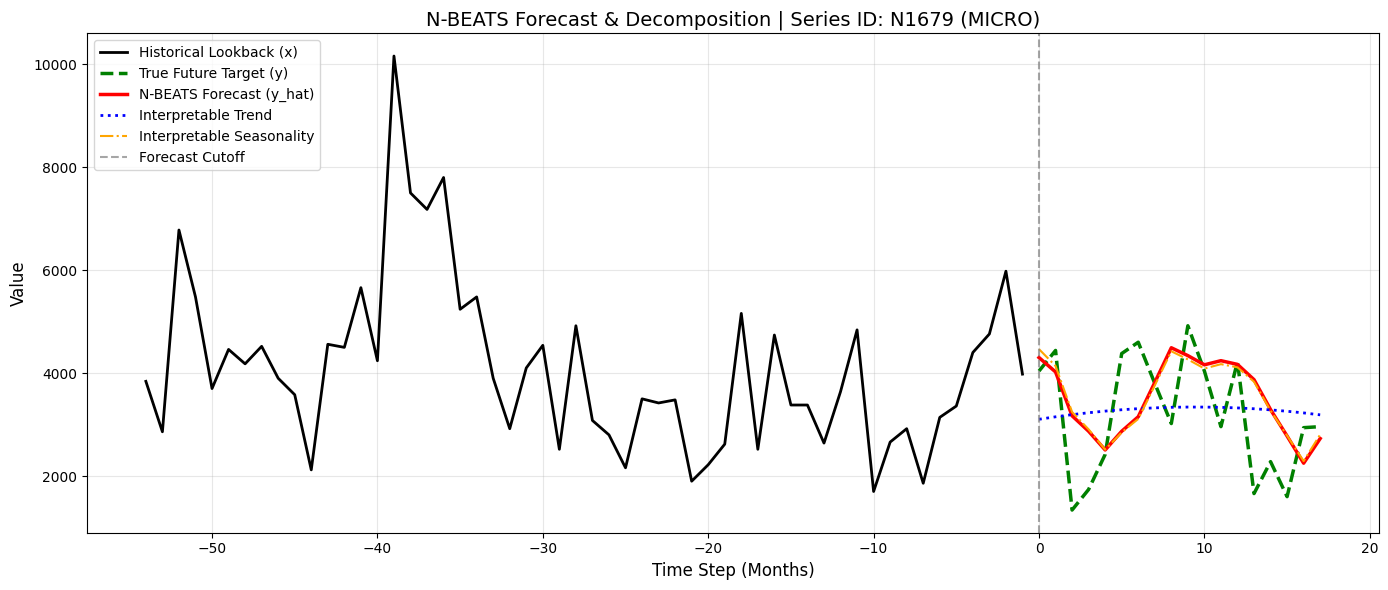

In [30]:
import matplotlib.pyplot as plt

# Set evaluation mode
model.eval()

# Select a sample series from series_pool
sample_series = series_pool[0]  # First series
x_hist = sample_series["train_hist"][-T_IN:]
y_true = sample_series["test_target"]

# Prepare input tensor
x_tensor = torch.tensor(x_hist, dtype=torch.float32).unsqueeze(0).to(DEVICE)

# Run model pass to get full forecast + interpretable components
with torch.no_grad():
    y_pred, y_trend, y_season = model(x_tensor)

# Convert outputs to 1D NumPy arrays
y_pred = y_pred.squeeze(0).cpu().numpy()
y_trend = y_trend.squeeze(0).cpu().numpy()
y_season = y_season.squeeze(0).cpu().numpy()

# Define time axes
t_hist = np.arange(-T_IN, 0)         # Lookback timeline (-54 to -1)
t_fore = np.arange(0, H)              # Forecast horizon timeline (0 to 17)

# Create Plot
plt.figure(figsize=(14, 6))

# 1. Historical Lookback
plt.plot(t_hist, x_hist, label="Historical Lookback (x)", color="black", linewidth=2)

# 2. Ground Truth Target
plt.plot(t_fore, y_true, label="True Future Target (y)", color="green", linestyle="--", linewidth=2.5)

# 3. N-BEATS Total Forecast
plt.plot(t_fore, y_pred, label="N-BEATS Forecast (y_hat)", color="red", linewidth=2.5)

# 4. Interpretable Trend Component
plt.plot(t_fore, y_trend, label="Interpretable Trend", color="blue", linestyle=":", linewidth=2)

# 5. Interpretable Seasonality Component (centered baseline offset)
plt.plot(t_fore, y_season + y_trend.mean(), label="Interpretable Seasonality", color="orange", linestyle="-.", linewidth=1.5)

# Formatting
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.7, label="Forecast Cutoff")
plt.title(f"N-BEATS Forecast & Decomposition | Series ID: {sample_series['id']} ({sample_series['category']})", fontsize=14)
plt.xlabel("Time Step (Months)", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

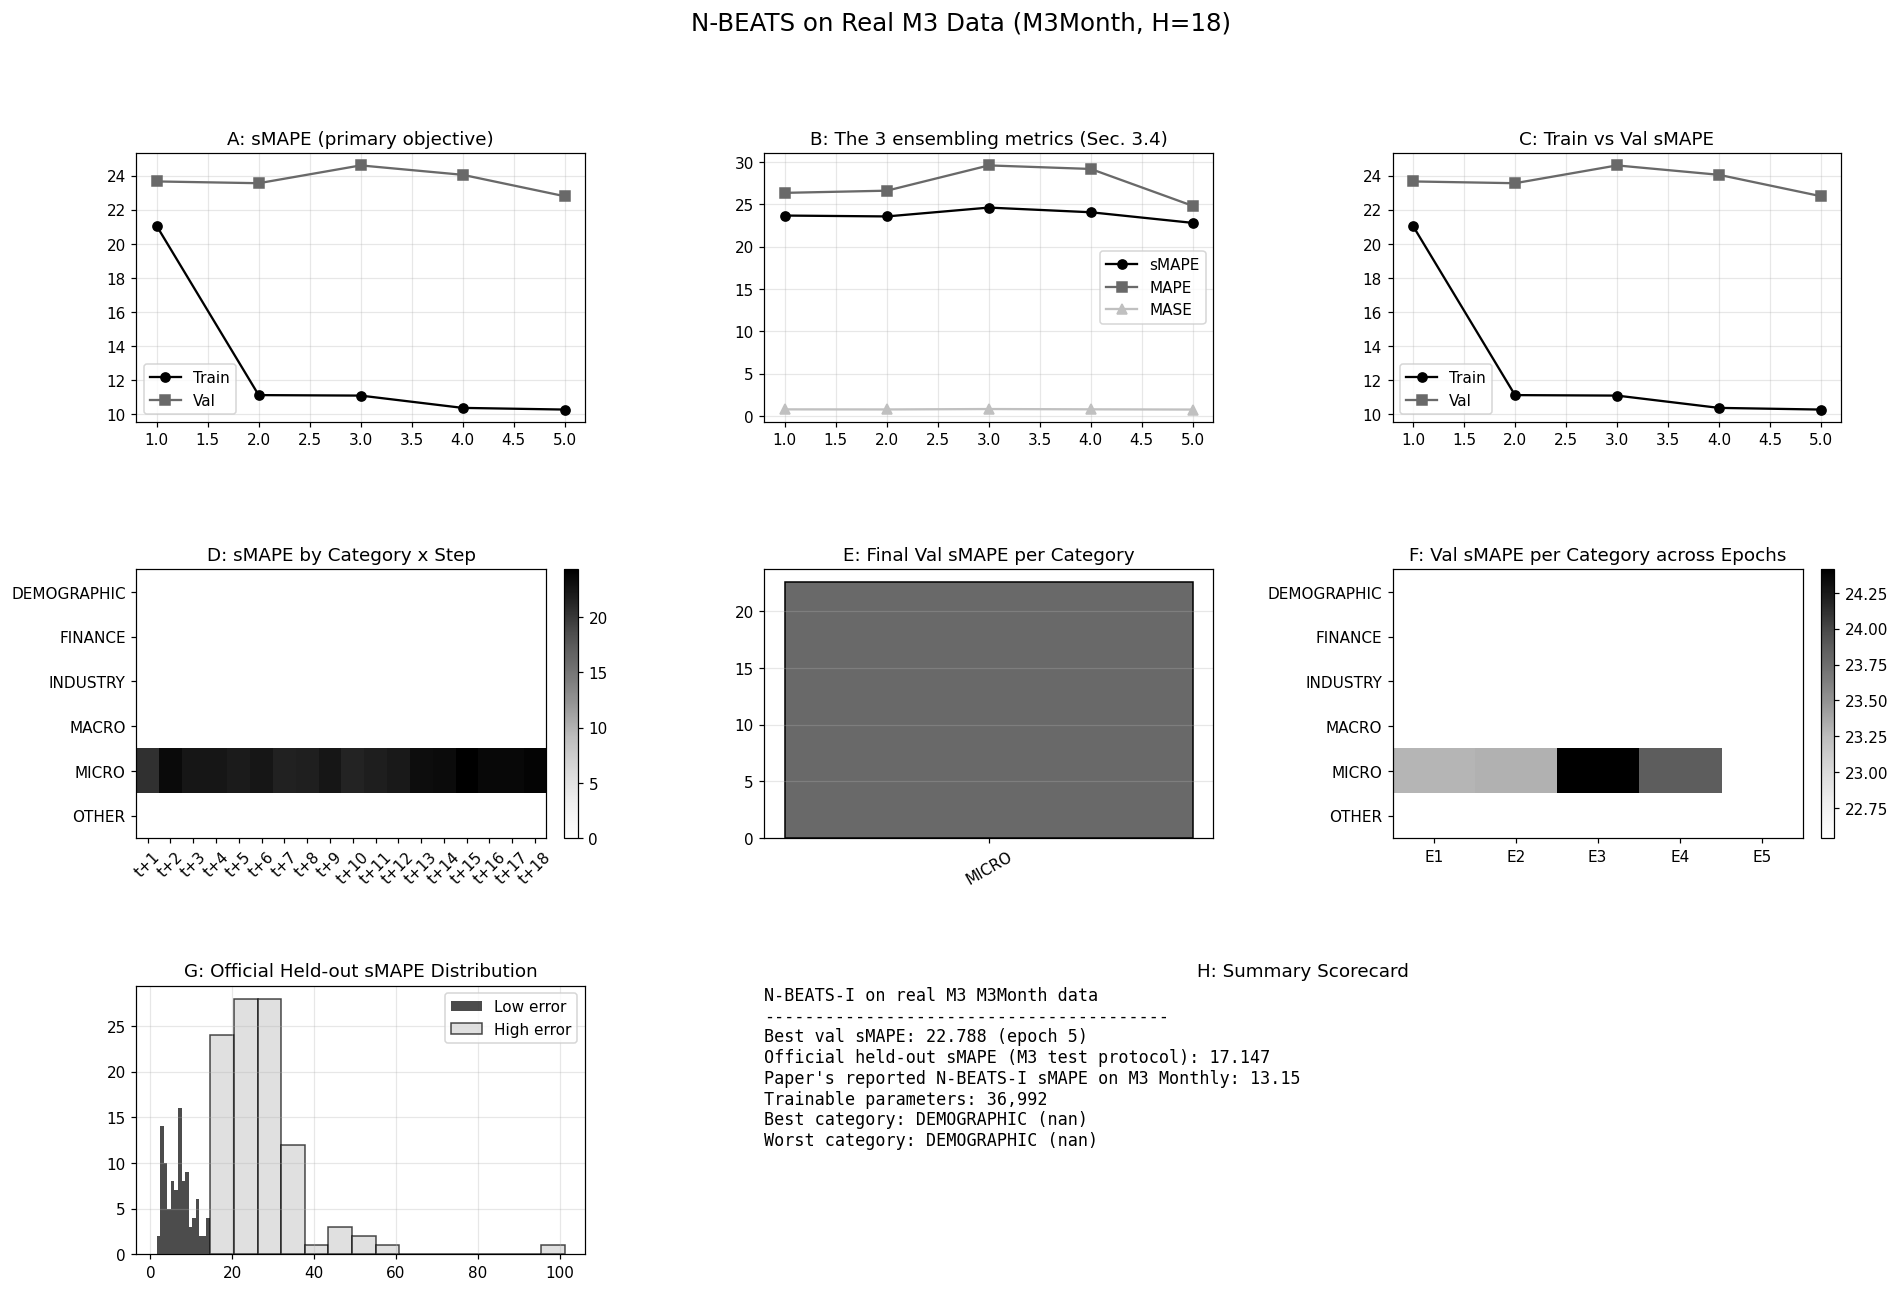

In [ ]:

# ============================================================
# 8. DASHBOARD (same 8-panel structure as before, now using
#    real M3 Categories as the per-class unit for panels D/E/F)
# ============================================================
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
                      "text.color":"black","axes.labelcolor":"black","xtick.color":"black",
                      "ytick.color":"black","axes.edgecolor":"black","legend.labelcolor":"black"})
fig = plt.figure(figsize=(20,13)); fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3,3, figure=fig, hspace=0.55, wspace=0.4)
ep_range = list(range(1, N_EPOCHS+1))

axA = fig.add_subplot(gs[0,0])
axA.plot(ep_range, history["train_smape"], "o-", color="black", label="Train")
axA.plot(ep_range, history["val_smape"], "s-", color="dimgray", label="Val")
axA.set_title("A: sMAPE (primary objective)", color="black"); axA.legend(); axA.grid(alpha=.3)

axB = fig.add_subplot(gs[0,1])
axB.plot(ep_range, history["val_smape"], "o-", color="black", label="sMAPE")
axB.plot(ep_range, history["val_mape"], "s-", color="dimgray", label="MAPE")
axB.plot(ep_range, history["val_mase"], "^-", color="silver", label="MASE")
axB.set_title("B: The 3 ensembling metrics (Sec. 3.4)", color="black"); axB.legend(); axB.grid(alpha=.3)

axC = fig.add_subplot(gs[0,2])
axC.plot(ep_range, history["train_smape"], "o-", color="black", label="Train")
axC.plot(ep_range, history["val_smape"], "s-", color="dimgray", label="Val")
axC.set_title("C: Train vs Val sMAPE", color="black"); axC.legend(); axC.grid(alpha=.3)

axD = fig.add_subplot(gs[1,0])
step_err = np.zeros((len(CATEGORIES), H)); cnt = np.zeros((len(CATEGORIES), H))
with torch.no_grad():
    for xb, yb, idxb in val_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        yh, _, _ = model(xb)
        se = (200.0*(yb-yh).abs()/((yb.abs()+yh.abs())+EPS)).cpu().numpy()
        cats = val_ds.cats[idxb.numpy()]
        for r, c in enumerate(CATEGORIES):
            m = cats == c
            if m.any(): step_err[r] += se[m].sum(0); cnt[r] += m.sum()
cnt[cnt == 0] = 1
step_err = step_err / cnt
im = axD.imshow(step_err, cmap="Greys", aspect="auto")
axD.set_xticks(range(H)); axD.set_xticklabels([f"t+{i+1}" for i in range(H)], rotation=45)
axD.set_yticks(range(len(CATEGORIES))); axD.set_yticklabels(CATEGORIES)
axD.set_title("D: sMAPE by Category x Step", color="black")
fig.colorbar(im, ax=axD, fraction=.046, pad=.04)

axE = fig.add_subplot(gs[1,1])
final_cat = {c: per_cat_history[c][-1] for c in CATEGORIES}
axE.bar(list(final_cat.keys()), list(final_cat.values()), color="dimgray", edgecolor="black")
axE.set_title("E: Final Val sMAPE per Category", color="black"); axE.tick_params(axis="x", rotation=30); axE.grid(alpha=.3, axis="y")

axF = fig.add_subplot(gs[1,2])
heat = np.array([per_cat_history[c] for c in CATEGORIES])
imF = axF.imshow(heat, cmap="Greys", aspect="auto")
axF.set_xticks(range(N_EPOCHS)); axF.set_xticklabels([f"E{e}" for e in ep_range])
axF.set_yticks(range(len(CATEGORIES))); axF.set_yticklabels(CATEGORIES)
axF.set_title("F: Val sMAPE per Category across Epochs", color="black")
fig.colorbar(imF, ax=axF, fraction=.046, pad=.04)

axG = fig.add_subplot(gs[2,0])
errs = np.array(official_errs); med = np.median(errs)
axG.hist(errs[errs<=med], bins=15, alpha=.7, color="black", label="Low error")
axG.hist(errs[errs>med], bins=15, alpha=.7, color="lightgray", edgecolor="black", label="High error")
axG.set_title("G: Official Held-out sMAPE Distribution", color="black"); axG.legend(); axG.grid(alpha=.3)

axH = fig.add_subplot(gs[2,1:]); axH.axis("off")
best_ep = int(np.argmin(history["val_smape"]))+1
summary = (f"N-BEATS-I on real M3 {FREQ} data\n" + "-"*40 + "\n"
           f"Best val sMAPE: {min(history['val_smape']):.3f} (epoch {best_ep})\n"
           f"Official held-out sMAPE (M3 test protocol): {np.mean(official_errs):.3f}\n"
           f"Paper's reported N-BEATS-I sMAPE on M3 Monthly: 13.15\n"
           f"Trainable parameters: {n_params:,}\n"
           f"Best category: {min(final_cat,key=final_cat.get)} ({min(final_cat.values()):.3f})\n"
           f"Worst category: {max(final_cat,key=final_cat.get)} ({max(final_cat.values()):.3f})\n")
axH.text(0,1,summary, fontsize=11, family="monospace", color="black", va="top")
axH.set_title("H: Summary Scorecard", color="black")

fig.suptitle(f"N-BEATS on Real M3 Data ({FREQ}, H={H})", fontsize=16, color="black")
buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, facecolor="white", bbox_inches="tight")
plt.close(fig); buf.seek(0); display(IPImage(data=buf.read()))